# DL. Эксперименты с нейронными сетями.

Шестой чекпойнт посвящен использованию нейронных сетей в задаче годового проекта.

От вас ожидается улучшение решения путем:
1) Использования подходящих для вашей задачи DL-архитектур (тексты - рекуррентные сети: RNN, LSTM, GRU)
2) Начать с простых архитектур и постепенно их усложнять по мере необходимости
3) Попробовать предобученные модели и их файнтюнинг

В результате экспериментов с DL-моделями необходимо составить таблицу с результатами экспериментов (отобразить модели, их архитектуры, гиперпараметры, результаты метрик, а также сравнить время обучения моделей).

Опишите лучшее DL-решение и обязательно сделайте выводы: обоснуйте, почему одна архитектура оказалась лучше другой? Также попробуйте объяснить, почему ML (или DL) оказался в вашей задаче лучше альтернативного подхода.

Затем сделайте общую таблицу сравнения всех подходов: baseline, лучшие ML-подходы, лучшие DL-подходы.

In [32]:
import re
import warnings
import time

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from scipy.sparse import hstack, csr_matrix

# import phik
# from phik import phik_matrix

import os
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence

from collections import Counter

warnings.filterwarnings("ignore")

random_state = 42
np.random.seed(random_state)
torch.manual_seed(random_state)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: { device }")

using device: cuda


In [33]:
df_path = 'dump_features_include_numeric.csv'
df = pd.read_csv(df_path, index_col=0)
display(df)

# select data from the cleanest datasets (0, 1) to train:
df_train = df[(df['dataset_id']==0) | (df['dataset_id']==1)]
df_train.dropna(subset='is_toxic', inplace=True)

# select data from the same source (vk), with the best results that BERT classifier predicted:
df_test = df[df['dataset_id']==7]

n_test_add = 60000
df_test = pd.concat([
    df_test,
    df[(df['dataset_id']==2) | (df['dataset_id']==3) | (df['dataset_id']==4) | (df['dataset_id']==5)].dropna(subset='is_toxic').sample(
        n=n_test_add,
        random_state=random_state,
    )
])

print(f'df_train shape: {df_train.shape}')
print(f'df_test shape: {df_test.shape}')

,raw_text_id,dataset_id,source_platform,is_verified,text_raw,is_toxic,toxicity_type,text_encoded_noninfrm,text_encoded_emoj_emotic,text_encoded_punct,...,is_bad_word_incl,has_pronouns,starts_with_cap,ends_with_dot,has_emotional_sym,has_repeating_letters_3plus,has_url,has_number,has_mention,has_hashtag
0,0,0,"2ch, pikabu",1,"Верблюдов-то за что? Дебилы, бл...\n",1.0,NaN,"Верблюдов-то за что? Дебилы, бл...","Верблюдов-то за что? Дебилы, бл...",Верблюдов[SPP_0]то за что[SPP_1] Дебилы[SPP_2]...,...,0,0,1,0,0,0,0,0,0,0
1,1,0,"2ch, pikabu",1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,NaN,"Хохлы, это отдушина затюканого россиянина, мол...","Хохлы, это отдушина затюканого россиянина, мол...",Хохлы[SPP_2] это отдушина затюканого россиянин...,...,0,0,1,1,0,0,0,0,0,0
2,2,0,"2ch, pikabu",1,Собаке - собачья смерть\n,1.0,NaN,Собаке - собачья смерть,Собаке - собачья смерть,Собаке [SPP_0] собачья смерть,...,0,0,1,0,0,0,0,0,0,0
3,3,0,"2ch, pikabu",1,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,NaN,"Страницу обнови, дебил. Это тоже не оскорблени...","Страницу обнови, дебил. Это тоже не оскорблени...",Страницу обнови[SPP_2] дебил[SPP_3] Это тоже н...,...,0,0,1,0,0,0,0,0,0,0
4,4,0,"2ch, pikabu",1,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,NaN,"тебя не убедил [NUM]-страничный пдф в том, что...","тебя не убедил [NUM]-страничный пдф в том, что...",тебя не убедил [NUM][SPP_0]страничный пдф в то...,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455550,455550,7,"Social Media, TV-Scripts (South Park)",0,"Fox News сообщил о работе Трампа в выходные, н...",0.0,NaN,"Fox News сообщил о работе Трампа в выходные, н...","Fox News сообщил о работе Трампа в выходные, н...",Fox News сообщил о работе Трампа в выходные[SP...,...,0,0,1,0,0,0,0,0,0,0
455551,455551,7,"Social Media, TV-Scripts (South Park)",0,Открыто новое достижение- выжил в России https...,0.0,NaN,Открыто новое достижение- выжил в России [URL],Открыто новое достижение- выжил в России [URL],Открыто новое достижение[SPP_0] выжил в России...,...,0,0,1,0,0,0,1,0,0,0
455552,455552,7,"Social Media, TV-Scripts (South Park)",0,"Митинговал ты, а страдает Пушкин https://t.co/...",0.0,NaN,"Митинговал ты, а страдает Пушкин [URL]","Митинговал ты, а страдает Пушкин [URL]",Митинговал ты[SPP_2] а страдает Пушкин [URL],...,0,0,1,0,0,0,1,0,0,0
455553,455553,7,"Social Media, TV-Scripts (South Park)",0,"'@max_katz Полицейское государство, в котором ...",1.0,NaN,"'[MNT] Полицейское государство, в котором не д...","'[MNT] Полицейское государство, в котором не д...",[RPP_483]MNT] Полицейское государство[SPP_2] в...,...,0,0,1,0,0,0,0,0,0,0


df_train shape: (252117, 34)
df_test shape: (61455, 34)


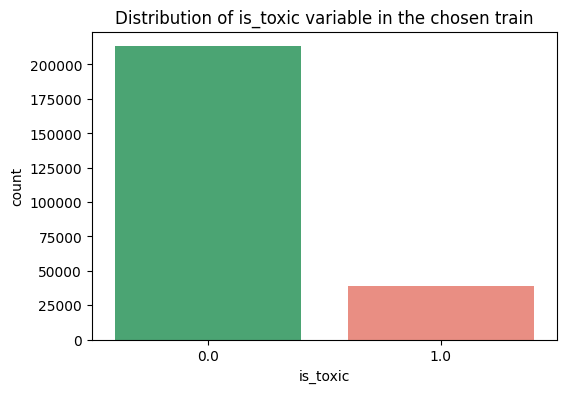

In [34]:
# count train is_toxic distribution:
plt.figure(figsize=(6,4))
sns.countplot(x='is_toxic', data=df_train.dropna(subset='is_toxic'), palette=['mediumseagreen','salmon'])
plt.title('Distribution of is_toxic variable in the chosen train')
plt.show()

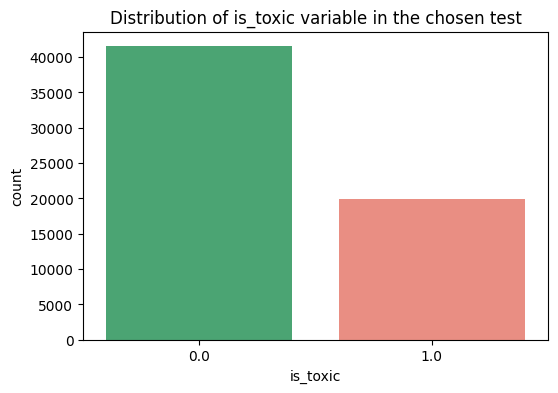

In [35]:
# count test is_toxic distribution:
plt.figure(figsize=(6,4))
sns.countplot(x='is_toxic', data=df_test, palette=['mediumseagreen','salmon'])
plt.title('Distribution of is_toxic variable in the chosen test')
plt.show()

In [36]:
X_train = df_train['text_del_stop_words'].values
y_train = df_train['is_toxic'].values

X_test = df_test['text_del_stop_words'].values
y_test = df_test['is_toxic'].values

train_mask = pd.notna(X_train) & (X_train != '') & (X_train != None)
X_train = X_train[train_mask]
y_train = y_train[train_mask]

test_mask = pd.notna(X_test) & (X_test != '') & (X_test != None)
X_test = X_test[test_mask]
y_test = y_test[test_mask]

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size = 0.2, random_state = random_state, stratify = y_train,
)

print(f'train size: { len(X_train) }')
print(f'val size: { len(X_val) }')
print(f'test size: { len(X_test) }')

train size: 201308
val size: 50327
test size: 61374


In [60]:
class_counts = np.bincount(y_train.astype(int))
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f'class weights:')
print(f'  non-toxic(0): { class_weights[0] }')
print(f'  toxic(1): { class_weights[1] }')

class weights:
  non-toxic(0): 0.3087805750392434
  toxic(1): 1.6912194249607566


# 1. Метрики

В качестве основной метрики была выбрана метрика `macro f1-score`
(не зависит от размеров классов, будут видны проблемы при работе с мелкими классами).

Дополнительно были рассмотрены
- `micro f1-score`,
- `weighted_f1`,
- `accuracy`,
- `precision`/`recall` по классам
- `ROC-AUC`

In [37]:
def calculate_all_metrics(y_true, y_pred, y_pred_proba=None):
    metrics = {}

    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['macro_f1'] = f1_score(y_true, y_pred, average='macro')
    metrics['micro_f1'] = f1_score(y_true, y_pred, average='micro')
    metrics['weighted_f1'] = f1_score(y_true, y_pred, average='weighted')

    metrics['macro_precision'] = precision_score(y_true, y_pred, average='macro')
    metrics['macro_recall'] = recall_score(y_true, y_pred, average='macro')

    precision_per_class = precision_score(y_true, y_pred, average=None)
    recall_per_class = recall_score(y_true, y_pred, average=None)
    f1_per_class = f1_score(y_true, y_pred, average=None)

    metrics['class_0_precision'] = precision_per_class[0]
    metrics['class_0_recall'] = recall_per_class[0]
    metrics['class_0_f1'] = f1_per_class[0]
    metrics['class_1_precision'] = precision_per_class[1]
    metrics['class_1_recall'] = recall_per_class[1]
    metrics['class_1_f1'] = f1_per_class[1]

    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba[:, 1])

    return metrics

def print_metrics(metrics, title='Метрики'):
    available_space = 100
    print('-' * available_space)
    print(title)
    print(f'macro f1-score: { metrics.get("macro_f1", "-") }')
    print('-' * available_space)

    print(f'accuracy: { metrics.get("accuracy", "-") }')
    print(f'micro f1-score: { metrics.get("micro_f1", "-") }')
    print(f'weighted f1-score: { metrics.get("weighted_f1", "-") }')
    print(f'macro precision: { metrics.get("macro_precision", "-") }')
    print(f'macro recall: { metrics.get("macro_recall", "-") }')

    if 'roc_auc' in metrics:
        print(f'ROC-AUC: {metrics["roc_auc"]}')

    print(f'\nМетрики по классам:')
    print(f'   non-toxic(0): Precision={metrics.get("class_0_precision", "-")}, '
          f'Recall={metrics.get("class_0_recall", "-")}, F1={metrics.get("class_0_f1", "-")}')
    print(f'   toxic(0): Precision={metrics.get("class_1_precision", "-")}, '
          f'Recall={metrics.get("class_1_recall", "-")}, F1={metrics.get("class_1_f1", "-")}')

    print('-' * available_space)

# 2. Подготовка данных

In [38]:
class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.word_freq = Counter()

    def build_vocabulary(self, texts):
        for text in texts:
            if isinstance(text, str) and text and not pd.isna(text):
                tokens = text.lower().split()
                self.word_freq.update(tokens)

        idx = 2
        for word, freq in self.word_freq.items():
            if freq >= self.min_freq:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1

        print(f'vocabulary size: { len(self.word2idx) }')
        print(f'most common words (10): { self.word_freq.most_common(10) }')

    def text_to_sequence(self, text):
        if not isinstance(text, str) or not text or pd.isna(text):
            return [self.word2idx['<UNK>']]
        tokens = text.lower().split()
        return [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]

    def __len__(self):
        return len(self.word2idx)

In [39]:
vocab = Vocabulary(min_freq=2)
vocab.build_vocabulary(X_train)

vocab_size = len(vocab)
print(f'final vocabulary size: { vocab_size }')

vocabulary size: 116927
most common words (10): [('[num]', 24645), ('[spp_2]', 10977), ('[spp_0]', 10111), ('[spp_3]', 6444), ('[spp_4]', 4015), ('б', 3017), ('[rpp_2]', 2697), ('пусть', 2646), ('[spp_1]', 2476), ('[rpp_0]', 2418)]
final vocabulary size: 116927


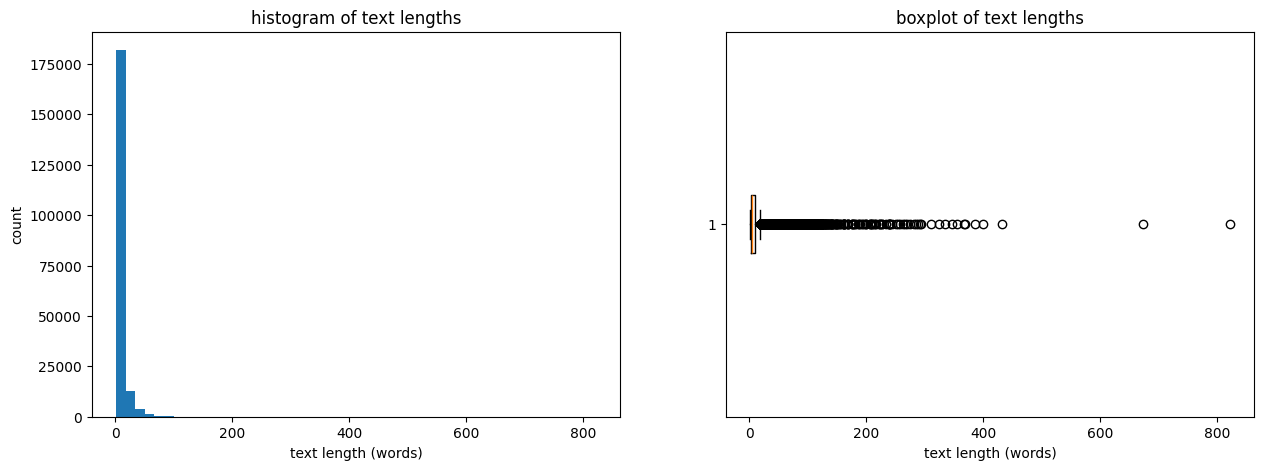

In [40]:
text_lengths = [len(str(text).split()) if pd.notna(text) and text else 0 for text in X_train]

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(text_lengths, bins = 50)
plt.xlabel('text length (words)')
plt.ylabel('count')
plt.title('histogram of text lengths')

plt.subplot(1, 2, 2)
plt.boxplot(text_lengths, vert = False)
plt.xlabel('text length (words)')
plt.title('boxplot of text lengths')

plt.show()

In [41]:
MAX_LEN = int(np.percentile(text_lengths, 95))

In [42]:
def pad_sequences(sequences, max_len, pad_value=0):
    padded = np.full((len(sequences), max_len), pad_value, dtype = np.long)
    for i, seq in enumerate(sequences):
        length = min(len(seq), max_len)
        padded[i, :length] = seq[:length]
    return padded

X_train_seq = [vocab.text_to_sequence(text) for text in X_train]
X_val_seq = [vocab.text_to_sequence(text) for text in X_val]
X_test_seq = [vocab.text_to_sequence(text) for text in X_test]

X_train_pad = pad_sequences(X_train_seq, MAX_LEN)
X_val_pad = pad_sequences(X_val_seq, MAX_LEN)
X_test_pad = pad_sequences(X_test_seq, MAX_LEN)

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_val_pad shape: {X_val_pad.shape}')
print(f'X_test_pad shape: {X_test_pad.shape}')

X_train_pad shape: (201308, 26)
X_val_pad shape: (50327, 26)
X_test_pad shape: (61374, 26)


In [43]:
class TextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)
test_dataset = TextDataset(X_test_pad, y_test)

print(f'train dataset size: {len(train_dataset)}')
print(f'val dataset size: {len(val_dataset)}')
print(f'test dataset size: {len(test_dataset)}')

train dataset size: 201308
val dataset size: 50327
test dataset size: 61374


In [44]:
def make_data_loaders(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

# 3. Применение нейронных сетей

In [45]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 2
DROPOUT = 0.5

BATCH_SIZE = 64
N_EPOCHS = 20
LEARNING_RATE = 0.001
PATIENCE = 3

In [46]:
train_loader, val_loader, test_loader = make_data_loaders(BATCH_SIZE)

print(f'train batches: {len(train_loader)}')
print(f'val batches: {len(val_loader)}')
print(f'test batches: {len(test_loader)}')

train batches: 3146
val batches: 787
test batches: 959


In [47]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim = EMBEDDING_DIM,
        hidden_dim = HIDDEN_DIM,
        output_dim = OUTPUT_DIM,
        n_layers = 1,
        bidirectional = False,
        dropout = DROPOUT,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = 0)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers = n_layers,
            bidirectional = bidirectional,
            dropout = dropout if n_layers > 1 else 0,
            batch_first = True,
        )

        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, hidden = self.rnn(embedded)

        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim = 1)
        else:
            hidden = hidden[-1,:,:]

        hidden = self.dropout(hidden)
        return self.fc(hidden)

In [48]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim = EMBEDDING_DIM,
        hidden_dim = HIDDEN_DIM,
        output_dim = OUTPUT_DIM,
        n_layers = 1,
        bidirectional = False,
        dropout = DROPOUT,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = 0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers = n_layers,
            bidirectional = bidirectional,
            dropout = dropout if n_layers > 1 else 0,
            batch_first = True,
        )

        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)

        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]

        hidden = self.dropout(hidden)
        return self.fc(hidden)

In [49]:
class GRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim = EMBEDDING_DIM,
        hidden_dim = HIDDEN_DIM,
        output_dim = OUTPUT_DIM,
        n_layers = 1,
        bidirectional = False,
        dropout = DROPOUT,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers = n_layers,
            bidirectional = bidirectional,
            dropout = dropout if n_layers > 1 else 0,
            batch_first = True,
        )

        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, hidden = self.gru(embedded)

        if self.gru.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]

        hidden = self.dropout(hidden)
        return self.fc(hidden)

In [50]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0

    for sequences, labels in dataloader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        predictions = model(sequences)
        loss = criterion(predictions, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [51]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    epoch_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for sequences, labels in dataloader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            predictions = model(sequences)
            loss = criterion(predictions, labels)
            epoch_loss += loss.item()

            probs = torch.softmax(predictions, dim = 1)
            preds = torch.argmax(predictions, dim = 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return epoch_loss / len(dataloader), np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [64]:
def train_and_evaluate_model(
    model,
    train_loader = train_loader,
    val_loader = val_loader,
    test_loader = test_loader,
    n_epochs = N_EPOCHS,
    learning_rate = LEARNING_RATE,
    patience = PATIENCE,
    device = device,
    use_class_weights = False
):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    if use_class_weights:
      class_weights_tensor.to(device)
      criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    else:
      criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    start_time = time.time()

    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, _, _, _ = evaluate(model, val_loader, criterion, device)

        print(f'epoch { epoch + 1 } / { n_epochs }: train loss: { train_loss }, val loss: { val_loss }')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'early stopping at epoch { epoch + 1 }')
                break

    training_time = time.time() - start_time

    model.load_state_dict(best_model_state)

    test_loss, test_preds, test_labels, test_probs = evaluate(model, test_loader, criterion, device)

    metrics = calculate_all_metrics(test_labels, test_preds, test_probs)
    metrics['test_loss'] = test_loss
    metrics['training_time'] = training_time

    print_metrics(metrics)
    print(f'test loss: { test_loss }')
    print(f'training time: { training_time }s')

    return metrics, model

In [53]:
def save_model(model, vocab, hyperparams, results, model_name, save_dir='models'):
    os.makedirs(save_dir, exist_ok=True)

    model_path = os.path.join(save_dir, f'{model_name}.pt')
    vocab_path = os.path.join(save_dir, f'{model_name}_vocab.pkl')
    info_path = os.path.join(save_dir, f'{model_name}_info.pkl')

    torch.save(model.state_dict(), model_path)

    with open(vocab_path, 'wb') as f:
        pickle.dump(vocab, f)

    info = {
        'hyperparams': hyperparams,
        'results': results,
        'model_name': model_name
    }
    with open(info_path, 'wb') as f:
        pickle.dump(info, f)

    print(f'saved to: { model_path }')
    print(f'  f1 (macro): { results["macro_f1"] }')


def load_model(model_class, model_name, save_dir='models', device='cpu'):
    model_path = os.path.join(save_dir, f'{model_name}.pt')
    vocab_path = os.path.join(save_dir, f'{model_name}_vocab.pkl')
    info_path = os.path.join(save_dir, f'{model_name}_info.pkl')

    with open(info_path, 'rb') as f:
        info = pickle.load(f)

    with open(vocab_path, 'rb') as f:
        vocab = pickle.load(f)

    hyperparams = info['hyperparams']
    model = model_class(
        vocab_size=hyperparams['vocab_size'],
        embedding_dim=hyperparams['embedding_dim'],
        hidden_dim=hyperparams['hidden_dim'],
        output_dim=hyperparams['output_dim'],
        n_layers=hyperparams['n_layers'],
        bidirectional=hyperparams['bidirectional'],
        dropout=hyperparams['dropout'],
    )

    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    print(f'loaded: { model_name }')
    print(f'  f1 (macro): { info["results"]["macro_f1"] }')

    return model, vocab, info

In [65]:
def run_dl_experiment(
    configurations,
    vocab = vocab,
    train_loader = train_loader,
    val_loader = val_loader,
    test_loader = test_loader,
    device = device,
    use_class_weights = False,
):
    results = []

    for i, config in enumerate(configurations, 1):
        model_name = config['name']
        print(f'\n\nconfig { i } / { len(configurations) }: { model_name }')

        model = config['model_class'](
            vocab_size = len(vocab),
            embedding_dim = config.get('embedding_dim', EMBEDDING_DIM),
            hidden_dim = config.get('hidden_dim', HIDDEN_DIM),
            output_dim = config.get('output_dim', OUTPUT_DIM),
            n_layers = config.get('n_layers', 1),
            bidirectional = config.get('bidirectional', False),
            dropout = config.get('dropout', DROPOUT),
        )

        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'number of trainable parameters: {n_params:,}')

        experiment_results, trained_model = train_and_evaluate_model(
            model,
            train_loader,
            val_loader,
            test_loader,
            n_epochs = config.get('n_epochs', N_EPOCHS),
            learning_rate = config.get('learning_rate', LEARNING_RATE),
            patience = config.get('patience', PATIENCE),
            device = device,
            use_class_weights = use_class_weights,
        )

        experiment_results['model_name'] = model_name
        experiment_results['n_layers'] = config.get('n_layers', 1)
        experiment_results['bidirectional'] = config.get('bidirectional', False)
        experiment_results['n_parameters'] = n_params
        experiment_results['model_class'] = config['model_class'].__name__

        hyperparams = {
            'vocab_size': len(vocab),
            'embedding_dim': config.get('embedding_dim', EMBEDDING_DIM),
            'hidden_dim': config.get('hidden_dim', HIDDEN_DIM),
            'output_dim': config.get('output_dim', OUTPUT_DIM),
            'n_layers': config.get('n_layers', 1),
            'bidirectional': config.get('bidirectional', False),
            'dropout': config.get('dropout', DROPOUT),
        }

        save_model(trained_model, vocab, hyperparams, experiment_results, model_name)

        results.append(experiment_results)
        print(f'\n{ model_name } finished: f1 = { experiment_results["macro_f1"] }')

    return results

In [55]:
all_results = []

In [56]:
configurations_rnn = [
    { 'name': 'RNN (1 layer)', 'model_class': RNNClassifier, 'n_layers': 1, 'bidirectional': False },
    { 'name': 'RNN (2 layers)', 'model_class': RNNClassifier, 'n_layers': 2, 'bidirectional': False },
    { 'name': 'BiRNN (1 layer)', 'model_class': RNNClassifier, 'n_layers': 1, 'bidirectional': True },
    { 'name': 'BiRNN (2 layers)', 'model_class': RNNClassifier, 'n_layers': 2, 'bidirectional': True },
]

all_results.extend(run_dl_experiment(configurations_rnn))



config 1 / 4: RNN (1 layer)
number of trainable parameters: 15,065,986
epoch 1 / 20: train loss: 0.43910389494930036, val loss: 0.44391123130633536
epoch 2 / 20: train loss: 0.4387349921781321, val loss: 0.43078233786353315
epoch 3 / 20: train loss: 0.4374938209867371, val loss: 0.4308992319253985
epoch 4 / 20: train loss: 0.4387637473268639, val loss: 0.4303676589585017
epoch 5 / 20: train loss: 0.4389030967625326, val loss: 0.43319245495063075
epoch 6 / 20: train loss: 0.4381055245241085, val loss: 0.43020804334323015
epoch 7 / 20: train loss: 0.4389096683830269, val loss: 0.4302198353686206
epoch 8 / 20: train loss: 0.4387559948532883, val loss: 0.43018320827653783
epoch 9 / 20: train loss: 0.4384608031910692, val loss: 0.4347183927230944
epoch 10 / 20: train loss: 0.4384713031953107, val loss: 0.4311669947155852
epoch 11 / 20: train loss: 0.4381871362988235, val loss: 0.4302330938614006
early stopping at epoch 11
-------------------------------------------------------------------

In [57]:
configurations_lstm = [
    { 'name': 'LSTM (1 layer)', 'model_class': LSTMClassifier, 'n_layers': 1, 'bidirectional': False },
    { 'name': 'LSTM (2 layers)', 'model_class': LSTMClassifier, 'n_layers': 2, 'bidirectional': False },
    { 'name': 'BiLSTM (1 layer)', 'model_class': LSTMClassifier, 'n_layers': 1, 'bidirectional': True },
    { 'name': 'BiLSTM (2 layers)', 'model_class': LSTMClassifier, 'n_layers': 2, 'bidirectional': True },
]

all_results.extend(run_dl_experiment(configurations_lstm))



config 1 / 4: LSTM (1 layer)
number of trainable parameters: 15,362,434
epoch 1 / 20: train loss: 0.36729764691343825, val loss: 0.24666724367282594
epoch 2 / 20: train loss: 0.250492171260652, val loss: 0.20914626069925488
epoch 3 / 20: train loss: 0.20390897695370638, val loss: 0.18951248737546736
epoch 4 / 20: train loss: 0.1738115496109302, val loss: 0.1857495391469217
epoch 5 / 20: train loss: 0.15369623365473933, val loss: 0.18726864839954896
epoch 6 / 20: train loss: 0.13795607341175162, val loss: 0.1839976331107839
epoch 7 / 20: train loss: 0.12668207754574606, val loss: 0.1927799694819951
epoch 8 / 20: train loss: 0.11673108935510078, val loss: 0.184724672084492
epoch 9 / 20: train loss: 0.10854066146575554, val loss: 0.20317210975485314
early stopping at epoch 9
----------------------------------------------------------------------------------------------------
Метрики
macro f1-score: 0.8014230268455866
-----------------------------------------------------------------------

In [58]:
configurations_gru = [
    { 'name': 'GRU (1 layer)', 'model_class': GRUClassifier, 'n_layers': 1, 'bidirectional': False },
    { 'name': 'GRU (2 layers)', 'model_class': GRUClassifier, 'n_layers': 2, 'bidirectional': False },
    { 'name': 'BiGRU (1 layer)', 'model_class': GRUClassifier, 'n_layers': 1, 'bidirectional': True },
    { 'name': 'BiGRU (2 layers)', 'model_class': GRUClassifier, 'n_layers': 2, 'bidirectional': True },
]

all_results.extend(run_dl_experiment(configurations_gru))



config 1 / 4: GRU (1 layer)
number of trainable parameters: 15,263,618
epoch 1 / 20: train loss: 0.3510771549489759, val loss: 0.2502827859534545
epoch 2 / 20: train loss: 0.24767058755840113, val loss: 0.20548998452297007
epoch 3 / 20: train loss: 0.20563805621006045, val loss: 0.19514597401856013
epoch 4 / 20: train loss: 0.17823232436470937, val loss: 0.18492459486625626
epoch 5 / 20: train loss: 0.158893449535713, val loss: 0.19898678149242224
epoch 6 / 20: train loss: 0.14414684414728596, val loss: 0.19003398128426627
epoch 7 / 20: train loss: 0.1331099721896761, val loss: 0.1880288466721243
early stopping at epoch 7
----------------------------------------------------------------------------------------------------
Метрики
macro f1-score: 0.7919894652277497
----------------------------------------------------------------------------------------------------
accuracy: 0.8407794831687685
micro f1-score: 0.8407794831687685
weighted f1-score: 0.8273459780271557
macro precision: 0.87

In [59]:
results_df = pd.DataFrame(all_results).sort_values('macro_f1', ascending=False)

print('Результаты:')

top_results = results_df.head(20)
display_cols = [
    'model_name',
    'macro_f1',
    'weighted_f1',
    'n_layers',
    'bidirectional',
    'n_parameters',
    'accuracy',
    'macro_precision',
    'macro_recall',
    'roc_auc',
    'training_time',
    ]
display(top_results[display_cols])

print('-' * 100)
best_result = results_df.iloc[0]

print(f'Лучший результат - {best_result["model_name"]}')
print(f'\nmacro f1-score: {best_result["macro_f1"]}')
print(f'accuracy: {best_result["accuracy"]}')
print(f'macro_precision: {best_result["macro_precision"]}')
print(f'macro_recall: {best_result["macro_recall"]}')
print(f'parameters: {best_result["n_parameters"]}')
print(f'training time: {best_result["training_time"]}s')

Результаты:


,model_name,macro_f1,weighted_f1,n_layers,bidirectional,n_parameters,accuracy,macro_precision,macro_recall,roc_auc,training_time
4,LSTM (1 layer),0.801423,0.834247,1,False,15362434,0.845472,0.871531,0.775725,0.860426,282.898486
10,BiGRU (1 layer),0.798531,0.832166,1,True,15560578,0.844120,0.873351,0.772298,0.863501,321.602429
7,BiLSTM (2 layers),0.797341,0.831154,2,True,17335170,0.843142,0.871574,0.771300,0.865458,476.070296
5,LSTM (2 layers),0.795331,0.829512,2,False,15888770,0.841676,0.869666,0.769445,0.861710,352.730904
3,BiRNN (2 layers),0.793599,0.826922,2,True,15559554,0.837276,0.851122,0.770767,0.840253,433.675910
2,BiRNN (1 layer),0.793561,0.827899,1,True,15165314,0.839932,0.865374,0.768220,0.849576,345.438389
9,GRU (2 layers),0.792256,0.827345,2,False,15658370,0.840372,0.872296,0.765793,0.866560,294.625973
8,GRU (1 layer),0.791989,0.827346,1,False,15263618,0.840779,0.875735,0.765038,0.868028,216.909134
11,BiGRU (2 layers),0.791047,0.826483,2,True,16743298,0.839834,0.873187,0.764404,0.865054,553.553310
6,BiLSTM (1 layer),0.790529,0.826054,1,True,15758210,0.839443,0.872587,0.763945,0.853872,337.418040


----------------------------------------------------------------------------------------------------
Лучший результат - LSTM (1 layer)

macro f1-score: 0.8014230268455866
accuracy: 0.8454720239840975
macro_precision: 0.8715310704641389
macro_recall: 0.7757249935811663
parameters: 15362434
Training time: 282.8984863758087s


In [66]:
configurations_rnn_with_cw = [
    { 'name': 'RNN (1 layer) with cw', 'model_class': RNNClassifier, 'n_layers': 1, 'bidirectional': False },
    { 'name': 'RNN (2 layers) with cw', 'model_class': RNNClassifier, 'n_layers': 2, 'bidirectional': False },
]

all_results.extend(run_dl_experiment(configurations_rnn_with_cw, use_class_weights = True))



config 1 / 2: RNN (1 layer) with cw
number of trainable parameters: 15,065,986
epoch 1 / 20: train loss: 0.7081626804482762, val loss: 0.69824176844981
epoch 2 / 20: train loss: 0.7084048555220152, val loss: 0.6961981860927887
epoch 3 / 20: train loss: 0.7085451461370024, val loss: 0.6947282767810846
epoch 4 / 20: train loss: 0.7089794763924586, val loss: 0.7002363058027197
epoch 5 / 20: train loss: 0.7087223656944461, val loss: 0.6947571646606756
epoch 6 / 20: train loss: 0.7090498733619028, val loss: 0.7006783528582416
early stopping at epoch 6
----------------------------------------------------------------------------------------------------
Метрики
macro f1-score: 0.4308209323343558
----------------------------------------------------------------------------------------------------
accuracy: 0.4332616417375436
micro f1-score: 0.4332616417375436
weighted f1-score: 0.4177398473518564
macro precision: 0.5232258821439753
macro recall: 0.5203364514148435
ROC-AUC: 0.5092050654837301



In [70]:
configurations_birnn_with_cw = [
    { 'name': 'BiRNN (1 layer) with cw', 'model_class': RNNClassifier, 'n_layers': 1, 'bidirectional': True },
    { 'name': 'BiRNN (2 layers) with cw', 'model_class': RNNClassifier, 'n_layers': 2, 'bidirectional': True },
]

all_results.extend(run_dl_experiment(configurations_birnn_with_cw, use_class_weights = True))



config 1 / 2: BiRNN (1 layer) with cw
number of trainable parameters: 15,165,314
epoch 1 / 20: train loss: 0.6342406699366427, val loss: 0.5001938209751813
epoch 2 / 20: train loss: 0.4819815610994295, val loss: 0.41384136985414666
epoch 3 / 20: train loss: 0.40443130275879935, val loss: 0.3615419433903058
epoch 4 / 20: train loss: 0.35467425069859926, val loss: 0.3544996052109453
epoch 5 / 20: train loss: 0.3067627711255916, val loss: 0.33438620582847767
epoch 6 / 20: train loss: 0.2884987996925481, val loss: 0.3228083394250088
epoch 7 / 20: train loss: 0.25732826861539276, val loss: 0.35996348022221764
epoch 8 / 20: train loss: 0.24247236700061867, val loss: 0.3794916578209953
epoch 9 / 20: train loss: 0.22697412465904465, val loss: 0.33549206712895
early stopping at epoch 9
----------------------------------------------------------------------------------------------------
Метрики
macro f1-score: 0.7847904840974099
------------------------------------------------------------------

In [67]:
configurations_lstm_with_cw = [
    { 'name': 'LSTM (1 layer) with cw', 'model_class': LSTMClassifier, 'n_layers': 1, 'bidirectional': False },
    { 'name': 'LSTM (2 layers) with cw', 'model_class': LSTMClassifier, 'n_layers': 2, 'bidirectional': False },
]

all_results.extend(run_dl_experiment(configurations_lstm_with_cw, use_class_weights = True))



config 1 / 2: LSTM (1 layer) with cw
number of trainable parameters: 15,362,434
epoch 1 / 20: train loss: 0.6761894392042651, val loss: 0.522901421429393
epoch 2 / 20: train loss: 0.4728808436407758, val loss: 0.3696990306601591
epoch 3 / 20: train loss: 0.3604998639692983, val loss: 0.3297785539014367
epoch 4 / 20: train loss: 0.30126077017243014, val loss: 0.31250725948787855
epoch 5 / 20: train loss: 0.26100536329743973, val loss: 0.3035836403164658
epoch 6 / 20: train loss: 0.23182970181685378, val loss: 0.3266402984267572
epoch 7 / 20: train loss: 0.20839016767928006, val loss: 0.3253881906027867
epoch 8 / 20: train loss: 0.18861278233065662, val loss: 0.39539591800965834
early stopping at epoch 8
----------------------------------------------------------------------------------------------------
Метрики
macro f1-score: 0.8081005719468692
----------------------------------------------------------------------------------------------------
accuracy: 0.8437286147228468
micro f1-sco

In [71]:
configurations_bilstm_with_cw = [
    { 'name': 'BiLSTM (1 layer) with cw', 'model_class': LSTMClassifier, 'n_layers': 1, 'bidirectional': True },
    { 'name': 'BiLSTM (2 layers) with cw', 'model_class': LSTMClassifier, 'n_layers': 2, 'bidirectional': True },
]

all_results.extend(run_dl_experiment(configurations_bilstm_with_cw, use_class_weights = True))



config 1 / 2: BiLSTM (1 layer) with cw
number of trainable parameters: 15,758,210
epoch 1 / 20: train loss: 0.54344530443401, val loss: 0.3888674533844297
epoch 2 / 20: train loss: 0.3884511183608662, val loss: 0.3347267599863958
epoch 3 / 20: train loss: 0.3171766041023142, val loss: 0.36145746593364764
epoch 4 / 20: train loss: 0.2693618566001477, val loss: 0.34023658628782594
epoch 5 / 20: train loss: 0.24044922419906004, val loss: 0.34575117356232643
early stopping at epoch 5
----------------------------------------------------------------------------------------------------
Метрики
macro f1-score: 0.8067408773041218
----------------------------------------------------------------------------------------------------
accuracy: 0.8389383126405319
micro f1-score: 0.8389383126405319
weighted f1-score: 0.8344257105301915
macro precision: 0.8283957185380237
macro recall: 0.7934147694915228
ROC-AUC: 0.8604265878129507

Метрики по классам:
   non-toxic(0): Precision=0.8510496352962107, R

In [68]:
configurations_gru_with_cw = [
    { 'name': 'GRU (1 layer) with cw', 'model_class': GRUClassifier, 'n_layers': 1, 'bidirectional': False },
    { 'name': 'GRU (2 layers) with cw', 'model_class': GRUClassifier, 'n_layers': 2, 'bidirectional': False },
]

all_results.extend(run_dl_experiment(configurations_gru_with_cw, use_class_weights = True))



config 1 / 2: GRU (1 layer) with cw
number of trainable parameters: 15,263,618
epoch 1 / 20: train loss: 0.5777430983008053, val loss: 0.41317257292691756
epoch 2 / 20: train loss: 0.3973614549938085, val loss: 0.3583216095837886
epoch 3 / 20: train loss: 0.32556473783490314, val loss: 0.3257515504766904
epoch 4 / 20: train loss: 0.2827845406324827, val loss: 0.3157602355376435
epoch 5 / 20: train loss: 0.24797951931682122, val loss: 0.34194276775345867
epoch 6 / 20: train loss: 0.22509185514174218, val loss: 0.3679854137517673
epoch 7 / 20: train loss: 0.20558771326337472, val loss: 0.35197161193913395
early stopping at epoch 7
----------------------------------------------------------------------------------------------------
Метрики
macro f1-score: 0.8154972603349614
----------------------------------------------------------------------------------------------------
accuracy: 0.8501156841659334
micro f1-score: 0.8501156841659334
weighted f1-score: 0.843546192037769
macro precision

In [72]:
configurations_bigru_with_cw = [
    { 'name': 'BiGRU (1 layer) with cw', 'model_class': GRUClassifier, 'n_layers': 1, 'bidirectional': True },
    { 'name': 'BiGRU (2 layers) with cw', 'model_class': GRUClassifier, 'n_layers': 2, 'bidirectional': True },
]

all_results.extend(run_dl_experiment(configurations_bigru_with_cw, use_class_weights = True))



config 1 / 2: BiGRU (1 layer) with cw
number of trainable parameters: 15,560,578
epoch 1 / 20: train loss: 0.5562602899689169, val loss: 0.3965886288063347
epoch 2 / 20: train loss: 0.3933644853792824, val loss: 0.3387801778967832
epoch 3 / 20: train loss: 0.32156894807878456, val loss: 0.3419623454746328
epoch 4 / 20: train loss: 0.2766824199427902, val loss: 0.34200157413526594
epoch 5 / 20: train loss: 0.2437481571981199, val loss: 0.3561143094325838
early stopping at epoch 5
----------------------------------------------------------------------------------------------------
Метрики
macro f1-score: 0.8099325342293815
----------------------------------------------------------------------------------------------------
accuracy: 0.8436634405448561
micro f1-score: 0.8436634405448561
weighted f1-score: 0.8380340125521555
macro precision: 0.8394210672937095
macro recall: 0.7935601917216162
ROC-AUC: 0.8597016172728663

Метрики по классам:
   non-toxic(0): Precision=0.848051210346937, Rec

In [73]:
results_df = pd.DataFrame(all_results).sort_values('macro_f1', ascending=False)

print('Результаты:')

top_results = results_df.head(24)
display_cols = [
    'model_name',
    'macro_f1',
    'weighted_f1',
    'n_layers',
    'bidirectional',
    'n_parameters',
    'accuracy',
    'macro_precision',
    'macro_recall',
    'roc_auc',
    'training_time',
    ]
display(top_results[display_cols])

print('-' * 100)
best_result = results_df.iloc[0]

print(f'Лучший результат - {best_result["model_name"]}')
print(f'\nmacro f1-score: {best_result["macro_f1"]}')
print(f'accuracy: {best_result["accuracy"]}')
print(f'macro_precision: {best_result["macro_precision"]}')
print(f'macro_recall: {best_result["macro_recall"]}')
print(f'parameters: {best_result["n_parameters"]}')
print(f'training time: {best_result["training_time"]}s')

Результаты:


,model_name,macro_f1,weighted_f1,n_layers,bidirectional,n_parameters,accuracy,macro_precision,macro_recall,roc_auc,training_time
16,GRU (1 layer) with cw,0.815497,0.843546,1,False,15263618,0.850116,0.853593,0.796158,0.864477,213.212905
21,BiLSTM (2 layers) with cw,0.814877,0.843367,2,True,17335170,0.850474,0.856938,0.794428,0.861081,532.148695
17,GRU (2 layers) with cw,0.810470,0.839726,2,False,15658370,0.847134,0.853038,0.790090,0.863554,253.938604
22,BiGRU (1 layer) with cw,0.809933,0.838034,1,True,15560578,0.843663,0.839421,0.793560,0.859702,172.960548
15,LSTM (2 layers) with cw,0.809274,0.839123,2,False,15888770,0.847199,0.856612,0.787725,0.859515,356.766113
23,BiGRU (2 layers) with cw,0.808665,0.838686,2,True,16743298,0.846906,0.856879,0.786934,0.863327,345.802872
14,LSTM (1 layer) with cw,0.808101,0.837120,1,False,15362434,0.843729,0.843795,0.789787,0.855066,252.499217
20,BiLSTM (1 layer) with cw,0.806741,0.834426,1,True,15758210,0.838938,0.828396,0.793415,0.860427,186.426056
4,LSTM (1 layer),0.801423,0.834247,1,False,15362434,0.845472,0.871531,0.775725,0.860426,282.898486
10,BiGRU (1 layer),0.798531,0.832166,1,True,15560578,0.844120,0.873351,0.772298,0.863501,321.602429


----------------------------------------------------------------------------------------------------
Лучший результат - GRU (1 layer) with cw

macro f1-score: 0.8154972603349614
accuracy: 0.8501156841659334
macro_precision: 0.8535934392359509
macro_recall: 0.7961579613940439
parameters: 15263618
training time: 213.21290516853333s


# Лучший результат
- Лучшая DL модель - `GRU (1 layer) with class weights`
- `macro f1-score` = `0.8155`
- `accuracy` = `0.8501`
- Количество параметров: `15,263,618`

## Сравнение всех подходов:

| Подход | Модель | macro f1-score |
|--------|--------|----------------|
| ML (линейные) | LinearSVC | 0.9063 |
| DL (предобученные) | BERT fine-tuning | 0.90 |
| ML (нелинейные) | CatBoostClassifier | 0.8782 |
| DL (с class weights) | GRU with cw | 0.8155 |
| DL (базовые) | LSTM | 0.8014 |

# Выводы
- Использование `class weights` важно для работы с несбалансированными данными в задаче классификации токсичности (особенно видно на примере `RNN`).
- `GRU` показал лучшие результаты среди всех других архитектур (`RNN`, `LSTM`, `GRU`).
- `Bidirectional` модели не дали значительного улучшения качества (но в случае `RNN` без `class weights` разница заметна).
- `BERT` показал результаты, сопоставимые с `LinearSVC`(см. `finetune_BERT.ipynb`).
- Предобученные модели эффективны, но требуют больше ресурсов.

# Почему DL-модели не превзошли ML-подходы:
- Недостаточный объем данных.
- Короткие тексты (в коротких сообщениях нет сложных долгосрочных зависимостей, которые требуют рекуррентных сетей).
- Простые паттерны токсичности (токсичность часто определяется конкретными словами/фразами, которые TF-IDF захватывает лучше).

Таким образом, для задачи классификации токсичных сообщений на данном датасете  ML методы (LinearSVC + TF-IDF + числовые признаки) являются оптимальным выбором по соотношению качество/сложность. DL-модели показали приемлемые результаты, но их стоит улучшать для получения лучших результатов.
